<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [4]:
!pip install pandas
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


#### Step 1: Load the dataset


In [5]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




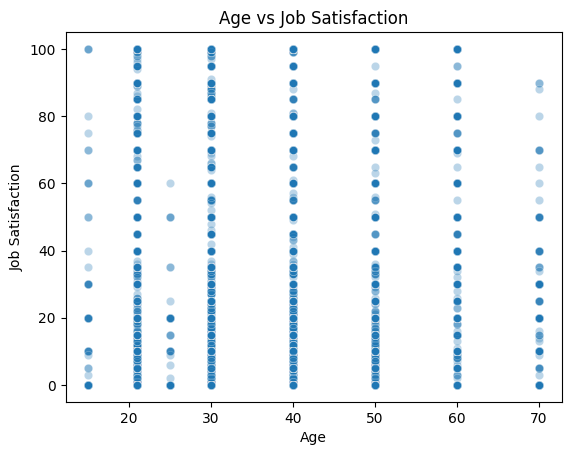

In [6]:
# Turn Age into numbers
age_map = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70,
    'Prefer not to say': 25
}
df['Age_numeric'] = df['Age'].map(age_map)

# Draw scatter plot
sns.scatterplot(x='Age_numeric', y='JobSatPoints_6', data=df, alpha=0.3)
plt.title("Age vs Job Satisfaction")
plt.xlabel("Age")
plt.ylabel("Job Satisfaction")
plt.show()

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


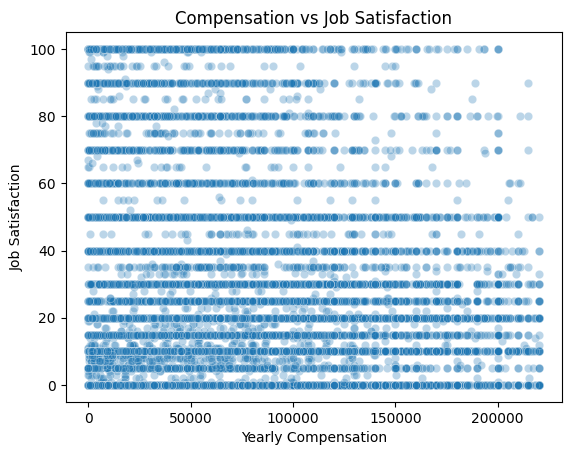

In [7]:
# Remove outliers from compensation
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df_clean = df[(df['ConvertedCompYearly'] >= lower) & (df['ConvertedCompYearly'] <= upper)]

# Draw scatter plot
sns.scatterplot(x='ConvertedCompYearly', y='JobSatPoints_6', data=df_clean, alpha=0.3)
plt.title("Compensation vs Job Satisfaction")
plt.xlabel("Yearly Compensation")
plt.ylabel("Job Satisfaction")
plt.show()

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


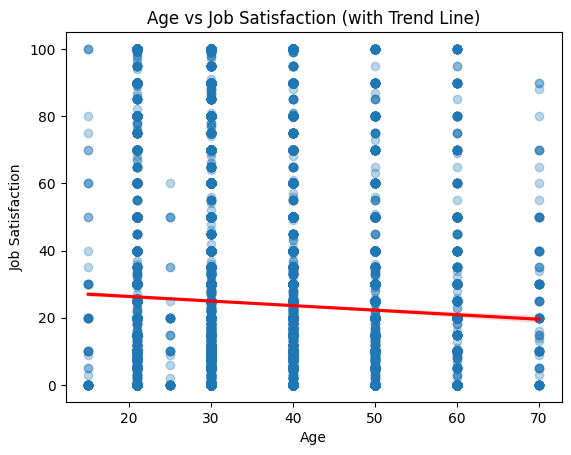

In [8]:
# Draw scatter plot WITH a trend line
sns.regplot(x='Age_numeric', y='JobSatPoints_6', data=df, 
            scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
plt.title("Age vs Job Satisfaction (with Trend Line)")
plt.xlabel("Age")
plt.ylabel("Job Satisfaction")
plt.show()

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


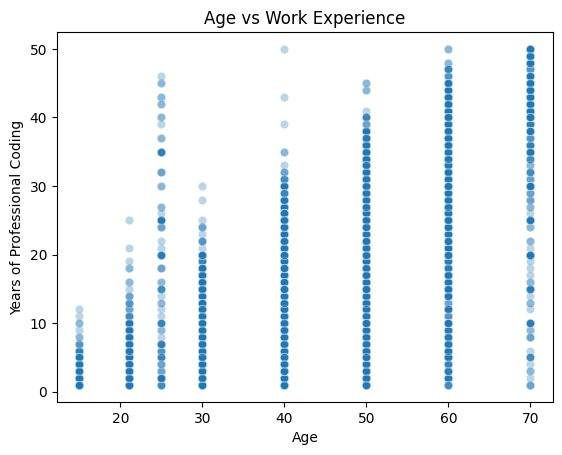

In [9]:
# Convert YearsCodePro to numbers
df['YearsCodePro_numeric'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

# Draw scatter plot
sns.scatterplot(x='Age_numeric', y='YearsCodePro_numeric', data=df, alpha=0.3)
plt.title("Age vs Work Experience")
plt.xlabel("Age")
plt.ylabel("Years of Professional Coding")
plt.show()

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


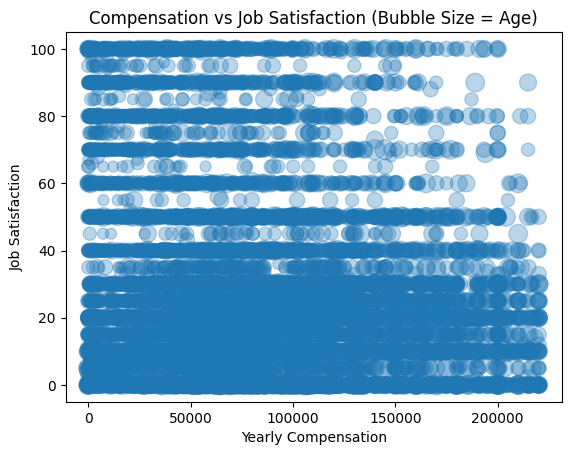

In [10]:
# Remove outliers from compensation
df_clean = df[(df['ConvertedCompYearly'] >= lower) & (df['ConvertedCompYearly'] <= upper)]

# Draw bubble plot
plt.scatter(x=df_clean['ConvertedCompYearly'], 
            y=df_clean['JobSatPoints_6'], 
            s=df_clean['Age_numeric'] * 3, 
            alpha=0.3)
plt.title("Compensation vs Job Satisfaction (Bubble Size = Age)")
plt.xlabel("Yearly Compensation")
plt.ylabel("Job Satisfaction")
plt.show()

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


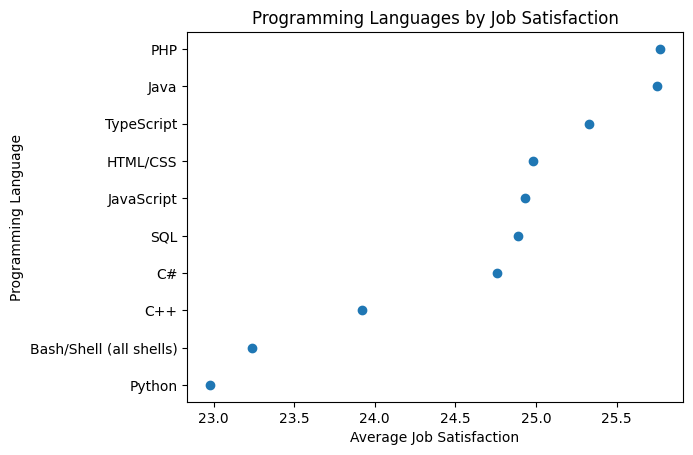

In [11]:
# Split languages apart (semicolons) and explode
df_lang = df[['LanguageHaveWorkedWith', 'JobSatPoints_6']].dropna()
df_lang = df_lang.assign(
    LanguageHaveWorkedWith=df_lang['LanguageHaveWorkedWith'].str.split(';')
).explode('LanguageHaveWorkedWith')

# Get top 10 languages
top10_langs = df_lang['LanguageHaveWorkedWith'].value_counts().head(10).index
df_lang_top = df_lang[df_lang['LanguageHaveWorkedWith'].isin(top10_langs)]

# Calculate average satisfaction for each language
lang_sat = df_lang_top.groupby('LanguageHaveWorkedWith')['JobSatPoints_6'].mean().sort_values()

# Draw scatter plot
plt.scatter(x=lang_sat.values, y=lang_sat.index)
plt.title("Programming Languages by Job Satisfaction")
plt.xlabel("Average Job Satisfaction")
plt.ylabel("Programming Language")
plt.show()

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


C:\Users\hasgh\AppData\Local\Temp\ipykernel_5144\4051759235.py:14: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


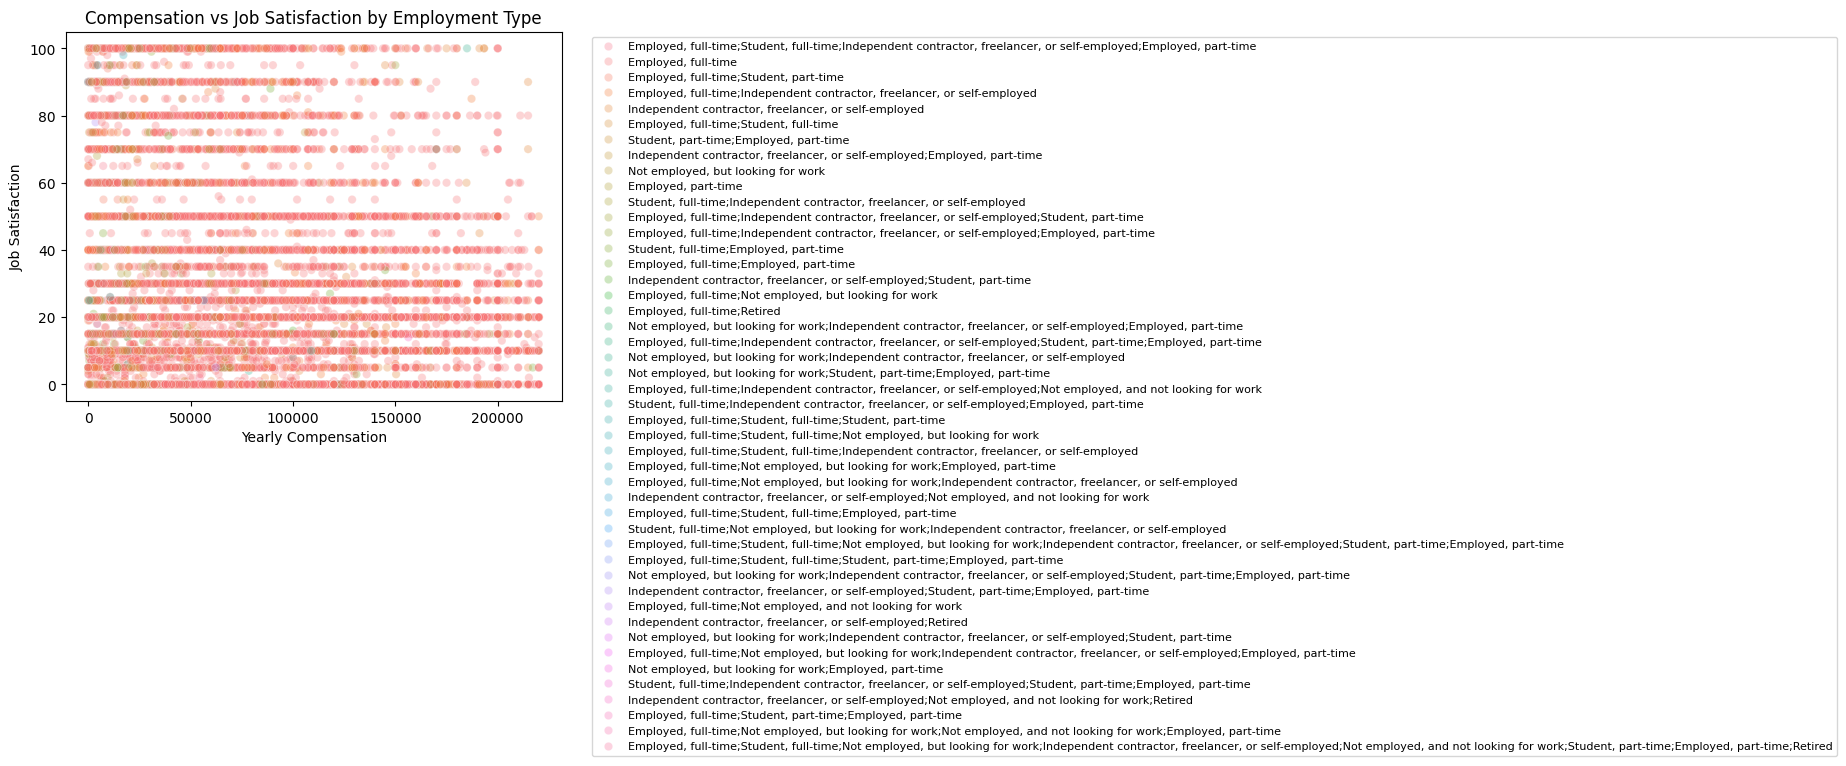

In [13]:
# Remove outliers
df_clean = df[(df['ConvertedCompYearly'] >= lower) & (df['ConvertedCompYearly'] <= upper)]

# Drop empty Employment rows
df_clean = df_clean.dropna(subset=['Employment', 'JobSatPoints_6'])

# Draw scatter plot with different colors for each employment type
sns.scatterplot(x='ConvertedCompYearly', y='JobSatPoints_6', 
                hue='Employment', data=df_clean, alpha=0.3)
plt.title("Compensation vs Job Satisfaction by Employment Type")
plt.xlabel("Yearly Compensation")
plt.ylabel("Job Satisfaction")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


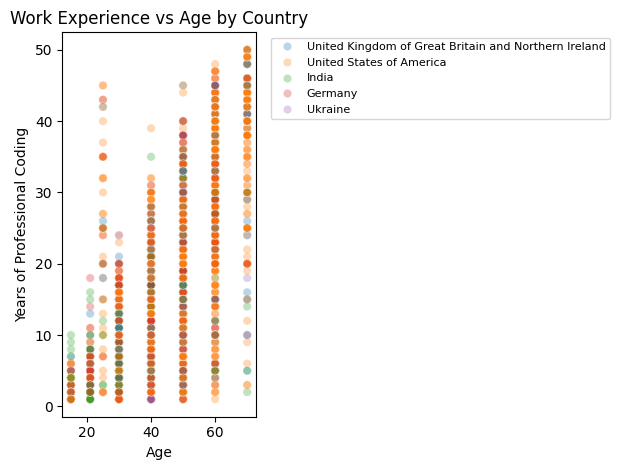

In [14]:
# Convert YearsCodePro to numbers
df['YearsCodePro_numeric'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

# Keep only top 5 countries
top5_countries = df['Country'].value_counts().head(5).index
df_top = df[df['Country'].isin(top5_countries)]

# Drop empty rows
df_top = df_top.dropna(subset=['YearsCodePro_numeric', 'Age_numeric', 'Country'])

# Draw scatter plot with colors for countries
sns.scatterplot(x='Age_numeric', y='YearsCodePro_numeric', 
                hue='Country', data=df_top, alpha=0.3)
plt.title("Work Experience vs Age by Country")
plt.xlabel("Age")
plt.ylabel("Years of Professional Coding")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
